## 3. Build Hybrid reduced-order Simulator and Scenario Checks


**Simulation Model scope**

The simulator is a hybrid reduced-order model. The recorded sensor series is used as the counterfactual baseline trajectory under no spray intervention. Spray actions are applied as short-duration perturbations on top of this baseline, rather than replacing the underlying observed dynamics.

The exact deodorant–TVOC dose-response curve is unknown since the underlying mechanisms are complex and depends on factors such as deodorant chemical properties, but the simulator assumes monotone nonlinear diminishing returns with respect to spray concentration. The chosen exponential saturation form is used only as a compact empirical representation of that assumption.

To summarize the modeling assumptions:

- The baseline data are treated as the no-intervention trajectory.
- action = 0 means no spray, so temperature, humidity, and TVOC follow the baseline plus noise only.
- Any nonzero action means one spray event with fixed total liquid volume/mass; the action level changes the active formulation concentration, not the sprayed water mass.
- Other spray factors such as droplet size, nozzle pattern, aerosol settling, spray placement, etc. are assumed such that a spray action only affects the next 5-minute interval for TVOC.
- Temperature and humidity are updated using a reduced psychrometric approximation, not a full condensation/CFD model.
- RH is clipped to [0, 100], and values near saturation are snapped to 100% for numerical stability.
- CO2 is not spray-driven since little to no literature exists on its response to spray interventions; it remains baseline plus noise.


**_OUTDATED:_** This needs to be updated to reflect the current state of the code, which has evolved since this was written. The general structure and assumptions may still hold, but specific details (e.g., parameter values, functional forms) may have changed.

**Temperature**

Spray-induced cooling is approximated from latent heat transfer using a lumped air-mass energy balance. This is a first-order estimate intended to capture the immediate thermal effect of water evaporation under fixed room geometry and fixed spray volume.

We estimate spray-induced cooling from latent heat transfer:

$$
\Delta T \approx \frac{m_{\text{water}}\,L}{m_{\text{air}}\,c_p}
\approx
\frac{1\,\text{kg}\times 2450\,\text{kJ/kg}}{1440\,\text{kg}\times 1.005\,\text{kJ/(kg * K)}}
\approx 1.7^\circ\text{C}
$$

with:

- $m_{\text{water}} = 1\,\text{kg}$ (1 L spray, assuming $\rho\approx1\,\text{kg/L}$)
- $L \approx 2450\text{kJ/kg}$ (latent heat of vaporization)
- $m_{\text{air}} \approx 1411\,\text{kg}$ (for $400\,\text{m}^2 \times 3\,\text{m}$ volume and $\rho_{\text{air}}\approx1.176\,\text{kg/m}^3$)
- $c_p \approx 1.005\text{kJ/(kg * K)}$ (specific heat capacity of air)

A temperature-dependent approximation for latent heat (FAO-56) is:

$$
L(T) = 2501 - 2.361\,T
$$

where $T$ is in $^\circ\text{C}$ and $L$ is in $\text{kJ/kg}$.

**Humidity**

Humidity is updated through humidity ratio and vapor-pressure conversion. The model assumes standard atmospheric pressure, a well-mixed room, and a short spray event whose evaporated water is added to the indoor moisture content. RH is capped at 100% to prevent unphysical values and to represent saturation.

We use **humidity ratio** (mass of water vapor per mass of dry air) to update RH after spray evaporation.

Let atmospheric pressure be $P\approx101.325\,\text{kPa}$.

1. Compute saturation vapor pressure at the new temperature (Tetens formula).
2. Compute initial vapor pressure: $e = RH \cdot e_s(T)$.
3. Convert to humidity ratio:

$$
w = 0.622\frac{e}{P-e}
$$

where $e$ is actual vapor pressure and $P$ is atmospheric pressure.

The relation comes from:

- Dalton's law: $P = P_d + e \Rightarrow P_d = P-e$
- Ideal gas law for each component
- The molecular-weight ratio of water vapor to dry air ($\approx0.622$)

Using ideal-gas forms,

$$
m_d = \frac{P_dV}{R_dT}, \quad m_v = \frac{eV}{R_vT}
$$

so

$$
W = \frac{m_v}{m_d}
= \frac{\frac{eV}{R_vT}}{\frac{P_dV}{R_dT}}
= \frac{eR_d}{P_dR_v}
\approx 0.622\frac{e}{P-e}
$$

Then we add evaporated spray mass to humidity ratio, convert updated $w$ back to vapor pressure, and compute updated RH as $e_{\text{new}}/e_s(T_{\text{new}})$.

**TVOC**

TVOC is modeled as a one-step intervention overlay on the baseline trajectory. Without spray, TVOC follows the observed sequence. With spray, the next time step is reduced by a nonlinear dose-response term derived from an exponential saturation curve, calibrated to an anchor point from the literature. This is a phenomenological surrogate, not a mechanistic chemical-transport model.

Without spray effects:

$$
\text{TVOC}_{t+1}=\text{TVOC}_t-\text{Decay}+\text{Emission}
$$

For first-order decay:

$$
C(t)=C_0e^{-kt}
$$

where $k$ can be related to ACH (often 6-10 in livestock housing).

This gives an implied emission term:

$$
\text{Emission}=\text{TVOC}_{t+1}-\text{TVOC}_t+\text{Decay}
$$

For spray effects, using literature as a rough prior (10.3389/fenvs.2022.1073835), define spray efficacy:

$$
e_{\text{spray}} = 0.649
$$

and model:

$$
\text{TVOC}_{t+1}=\text{TVOC}_t-\text{Decay}+\text{Emission}-e_{\text{spray}}\cdot\text{TVOC}_t
$$

To capture nonlinear diminishing returns, use a pseudo-first-order concentration model:

$$
C(t)=C_0e^{-k_{\text{rxn}}C_{\text{spray}}t}
$$

Let $\beta=k_{\text{rxn}}t$ (constant-contact-time lumping), then:

$$
C(t)=C_0e^{-\beta C_{\text{spray}}}
$$

and removal fraction is:

$$
\alpha = 1-e^{-\beta C_{\text{spray}}}
$$

Calibrate with $\alpha=0.649$ at $C_{\text{spray}}=1500\,\text{mg/L}$:

$$
0.649 = 1-e^{-1500\beta}
\Rightarrow e^{-1500\beta}=0.351
\Rightarrow \beta = -\frac{\ln(0.351)}{1500}
\approx 6.98\times10^{-4}\,\text{L/mg}
$$

So the calibrated efficacy curve is:

$$
\alpha(C_{\text{spray}})=1-\exp\!\left(-6.98\times10^{-4}\,C_{\text{spray}}\right)
$$


In [3]:
from dataclasses import dataclass, field

import numpy as np
import pandas as pd


ACTION_CONCENTRATIONS: tuple[int, ...] = (0, 500, 1000, 1500)


@dataclass(frozen=True)
class RewardWeights:
    tvoc_excess_scale: float = 1.0
    tvoc_target: float = 50.0

    thi_scale: float = 0.45
    rh_excess_scale: float = 0.15
    rh_target: float = 90.0
    cold_scale: float = 0.30

    action_scale: float = 1.0
    action_curve_power: float = 2.0
    action_curve_alpha_blend: float = 0.6
    action_urgency_scale: float = 0.0


# Normalization constants for reward components to keep them all in a reasonable range
# These were empirically chosen
TVOC_EXCESS_NORM = 18.5
# CO2_EXCESS_NORM = 144.0
THI_EXCESS_NORM = 0.0625
RH_EXCESS_NORM = 6.75
COLD_EXCESS_NORM = 0.040


@dataclass
class Pi1SimulatorConfig:
    gamma: float = 0.99

    ach = 6.0  # Assuming poultry house meets minimum recommended ACH per https://www.engineeringtoolbox.com/air-change-rate-room-d_867.html recommendation

    time_step_minutes: float = 5.0

    spray_mass_kg = 1.0  # Assuming density of 1 kg/L for the sprayed liquid

    # Room dimensions
    room_area_m2: float = 400.0
    room_height_m: float = 3.0
    room_volume_m3: float = room_area_m2 * room_height_m
    room_total_air_mass_kg: float = (
        room_volume_m3 * 1.176
    )  # kg/m3 at sea level (101325 Pa) and 27°C, calculated with https://www.engineeringtoolbox.com/air-density-specific-weight-d_600.html

    atmospheric_pressure_pa: float = 101325.0

    cp_air = 1.005  # kJ/(kg*K)

    # Noise scales
    tvoc_noise_sigma: float = 2.35
    rh_noise_sigma: float = 0.10
    co2_noise_sigma: float = 4.92
    temp_noise_sigma: float = 0.023

    reward: RewardWeights = field(default_factory=RewardWeights)


def wetbulb_stull(temp_c: float, rh: float) -> float:
    """
    https://industrialmonitordirect.com/blogs/knowledgebase/wet-bulb-temperature-calculation-for-industrial-hvac-systems
    """
    return (
        temp_c * np.arctan(0.151977 * np.sqrt(rh + 8.313659))
        + np.arctan(temp_c + rh)
        - np.arctan(rh - 1.676331)
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
        - 4.686035
    )


def tetens_saturation_vapor_pressure(temp_c: float) -> float:
    """
    Calculate saturation vapor pressure in hPa using Tetens formula
    https://www.sciencedirect.com/book/monograph/9780123869104/principles-of-environmental-physics
    """
    return 6.1078 * np.exp((17.27 * temp_c) / (temp_c + 237.3))


def to_humidity_ratio(
    temp_c: float | np.ndarray, rh: float | np.ndarray
) -> float | np.ndarray:
    """Convert temperature (°C) and RH (%) to humidity ratio (kg_v/kg_da).
    Derived from ideal gas law + Dalton's law + Tetens formula.
    https://wikipedia.org/wiki/Ideal_gas_law
    https://www.engineeringtoolbox.com/moist-air-daltons-law-d_678.html
    """
    e_s = tetens_saturation_vapor_pressure(temp_c)
    e = e_s * (rh / 100.0)
    P_hpa = 101325.0 / 100.0  # Pa -> hPa
    return 0.622 * e / (P_hpa - e)


def tvoc_spray_loss(dose_mg_L: float) -> float:
    """
    Simple model for TVOC reduction from spray dose.
    """
    beta = (
        -np.log(1 - 0.649) / 1500.0
    )  # Assuming 1500 mg/L gives 65% reduction at typical TVOC levels
    return 1 - np.exp(-beta * dose_mg_L)


class Pi1SpraySimulator:
    """Hybrid reduced-order simulator for RL prototyping on pi-1 5-minute data."""

    def __init__(
        self,
        pi1_df: pd.DataFrame,
        thanhhoa_weather_df: pd.DataFrame,
        config: Pi1SimulatorConfig | None = None,
        seed: int = 7,
    ) -> None:
        self.cfg = config or Pi1SimulatorConfig()
        self.rng = np.random.default_rng(seed)

        required_cols = ["tvoc", "co2", "temp", "humi"]
        base = pi1_df.copy()
        for col in required_cols:
            base[col] = pd.to_numeric(base[col], errors="coerce")
        base = base.dropna(subset=required_cols).reset_index(drop=True)

        self.real_tvoc = base["tvoc"].to_numpy(dtype=float)
        self.real_co2 = base["co2"].to_numpy(dtype=float)
        self.real_temp = base["temp"].to_numpy(dtype=float)
        self.real_rh = base["humi"].to_numpy(dtype=float)
        self.T = len(base)

        self.emission_tvoc = np.concatenate(
            [
                [0.0],
                self.real_tvoc[1:]
                - self.real_tvoc[:-1]
                * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0),
            ]
        )
        self.emission_co2 = np.concatenate(
            [
                [0.0],
                self.real_co2[1:]
                - self.real_co2[:-1]
                * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0),
            ]
        )

        # Loaded weather df should be already interpolated to 5-minute resolution
        self.weather_temp = thanhhoa_weather_df["weather_temp"].to_numpy(dtype=float)
        self.weather_rh = thanhhoa_weather_df["weather_rhum"].to_numpy(dtype=float)

        self.weather_w = to_humidity_ratio(self.weather_temp, self.weather_rh)
        self.real_w = to_humidity_ratio(self.real_temp, self.real_rh)

        self.emission_temp = np.concatenate(
            [
                [0.0],
                (
                    self.real_temp[1:]
                    - self.weather_temp[1:]
                    - (self.real_temp[:-1] - self.weather_temp[1:])
                    * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0)
                ),
            ]
        )

        self.emission_w = np.concatenate(
            [
                [0.0],
                (
                    self.real_w[1:]
                    - self.weather_w[1:]
                    - (self.real_w[:-1] - self.weather_w[1:])
                    * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0)
                ),
            ]
        )

    @staticmethod
    def action_space() -> list[int]:
        return list(ACTION_CONCENTRATIONS)

    def reset(self, t0: int = 0) -> np.ndarray:
        t0 = int(np.clip(t0, 0, self.T - 1))
        self._w_sim = self.real_w[t0]
        return np.array(
            [
                self.real_tvoc[t0],
                self.real_co2[t0],
                self.real_temp[t0],
                self.real_rh[t0],
            ],
            dtype=float,
        )

    def step(self, state: np.ndarray, action: int, t: int) -> np.ndarray:
        t = int(np.clip(t, 0, self.T - 2))

        decay = np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0)

        tvoc_sim, co2_sim, temp_sim, rh_sim = state

        # TVOC
        beta = (
            -np.log(1 - 0.649) / 1500.0
        )  # Assuming 1500 mg/L gives 65% reduction at typical TVOC levels
        tvoc_spray_removal = (1 - np.exp(-beta * action)) * tvoc_sim
        tvoc_next = (
            tvoc_sim * decay
            + self.emission_tvoc[t + 1]
            - tvoc_spray_removal
            + self.rng.normal(0.0, self.cfg.tvoc_noise_sigma)
        )
        tvoc_next = max(0.0, tvoc_next)

        # CO2
        co2_next = (
            co2_sim * decay
            + self.emission_co2[t + 1]
            + self.rng.normal(0.0, self.cfg.co2_noise_sigma)
        )
        co2_next = max(0.0, co2_next)

        # Temperature and RH
        P_hpa = self.cfg.atmospheric_pressure_pa / 100.0

        # Mass balance with outdoor anchor
        temp_mb = (
            self.weather_temp[t + 1]
            + (temp_sim - self.weather_temp[t + 1])
            * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0)
            + self.emission_temp[t + 1]
            + self.rng.normal(0.0, self.cfg.temp_noise_sigma)
        )
        w_mb = (
            self.weather_w[t + 1]
            + (self._w_sim - self.weather_w[t + 1])
            * np.exp(-self.cfg.ach * self.cfg.time_step_minutes / 60.0)
            + self.emission_w[t + 1]
        )

        # Noise scaled from RH-space to w-space: dw/dRH ~= 0.622 * e_s / (100 * P)
        # Valid approximation when e << P, which holds for atmospheric conditions
        e_s_mb = tetens_saturation_vapor_pressure(temp_mb)
        sigma_w = self.cfg.rh_noise_sigma * (0.622 * e_s_mb / (100.0 * P_hpa))
        w_mb += self.rng.normal(0.0, sigma_w)
        w_mb = max(0.0, w_mb)  # physical lower bound

        if action > 0:
            # Wetbulb needs RH — derive from w_mb at temp_mb before applying spray
            e_mb = (w_mb * P_hpa) / (0.622 + w_mb)
            rh_for_wb = float(np.clip((e_mb / e_s_mb) * 100.0, 0.0, 100.0))

            wetbulb = wetbulb_stull(temp_mb, rh_for_wb)
            L = 2501 - 2.369 * temp_mb  # FAO-56 latent heat (kJ/kg)
            temp_drop = (self.cfg.spray_mass_kg * L) / (
                self.cfg.room_total_air_mass_kg * self.cfg.cp_air
            )
            temp_next = max(wetbulb, temp_mb - temp_drop)

            actual_temp_drop = temp_mb - temp_next
            actual_evap_kg = (
                actual_temp_drop * self.cfg.room_total_air_mass_kg * self.cfg.cp_air
            ) / L
            w_next = w_mb + actual_evap_kg / self.cfg.room_total_air_mass_kg
        else:
            temp_next = temp_mb
            w_next = w_mb

        # Derive RH from simulated w and T
        e_final = (w_next * P_hpa) / (0.622 + w_next)
        e_s_final = tetens_saturation_vapor_pressure(temp_next)
        rh_next = float(np.clip((e_final / e_s_final) * 100.0, 0.0, 100.0))
        if rh_next >= 99.5:
            rh_next = 100.0

        self._w_sim = w_next  # persist hidden state for next step

        return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

    def rollout(self, actions: list[int], t0: int = 0) -> pd.DataFrame:
        """Run one trajectory and return a DataFrame for quick inspection."""
        t = int(np.clip(t0, 0, self.T - 2))
        state = self.reset(t)

        rows: list[dict[str, float | int]] = [
            {
                "t": t,
                "action": 0,
                "tvoc": state[0],
                "co2": state[1],
                "temp": state[2],
                "rh": state[3],
            }
        ]

        for a in actions:
            next_state = self.step(state, int(a), t)
            t += 1
            rows.append(
                {
                    "t": t,
                    "action": int(a),
                    "tvoc": next_state[0],
                    "co2": next_state[1],
                    "temp": next_state[2],
                    "rh": next_state[3],
                }
            )
            state = next_state

            if t >= self.T - 2:
                break

        return pd.DataFrame(rows)

    def compute_reward(
        self,
        tvoc_prev: float,
        tvoc_next: float,
        temp_prev: float,
        temp_next: float,
        rh_prev: float,
        rh_next: float,
        action: int,
        reward_weights: RewardWeights | None = None,
        is_terminal: bool = False,
    ) -> float:
        w = reward_weights or self.cfg.reward

        tvoc_excess = max(0.0, tvoc_next - w.tvoc_target) / TVOC_EXCESS_NORM
        tvoc_excess_term = -w.tvoc_excess_scale * tvoc_excess

        thi_prev = (0.8 * temp_prev) + ((rh_prev / 100.0) * (temp_prev - 14.4)) + 46.4
        thi_next = (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4

        thi_term = (
            -w.thi_scale * max(0.0, thi_next - max(73.0, thi_prev)) / THI_EXCESS_NORM
        )
        rh_term = -w.rh_excess_scale * max(0.0, rh_next - w.rh_target) / RH_EXCESS_NORM
        cold_term = -w.cold_scale * max(0.0, 18.0 - temp_next) / COLD_EXCESS_NORM

        tvoc_urgency = np.clip(
            (tvoc_prev - (w.tvoc_target * 0.5)) / max(1.0, w.tvoc_target),
            0.0,
            1.0,
        )
        dose_norm = float(action) / 1500.0
        urgency_multiplier = 1.0 + w.action_urgency_scale * (1.0 - tvoc_urgency)
        action_term = (
            -w.action_scale
            * (
                w.action_curve_alpha_blend * dose_norm
                + (1 - w.action_curve_alpha_blend) * dose_norm**w.action_curve_power
            )
            * urgency_multiplier
        )

        base_reward = tvoc_excess_term + thi_term + rh_term + cold_term + action_term

        # PBRS shaping term.
        phi_prev = self._phi(tvoc_prev, temp_prev, rh_prev, w)
        phi_next = self._phi(tvoc_next, temp_next, rh_next, w)
        shaping = 0.0 if is_terminal else (self.cfg.gamma * phi_next - phi_prev)

        return float(base_reward + shaping)

    def _phi(
        self,
        tvoc: float,
        temp: float,
        rh: float,
        w: RewardWeights,
    ) -> float:
        thi = (0.8 * temp) + ((rh / 100.0) * (temp - 14.4)) + 46.4

        tvoc_excess = max(0.0, tvoc - w.tvoc_target) / TVOC_EXCESS_NORM
        thi_excess = max(0.0, thi - 73.0) / THI_EXCESS_NORM
        rh_excess = max(0.0, rh - w.rh_target) / RH_EXCESS_NORM
        cold_excess = max(0.0, 18.0 - temp) / COLD_EXCESS_NORM

        # Potential is higher for better states, so return a negative penalty sum.
        return -(
            w.tvoc_excess_scale * tvoc_excess
            + w.thi_scale * thi_excess
            + w.rh_excess_scale * rh_excess
            + w.cold_scale * cold_excess
        )


### Scenario plots (TVOC, CO2, temperature, RH, action schedules) and reward term balance analysis.


Simulator initialized: T=4873 steps, action_space=[0, 500, 1000, 1500]


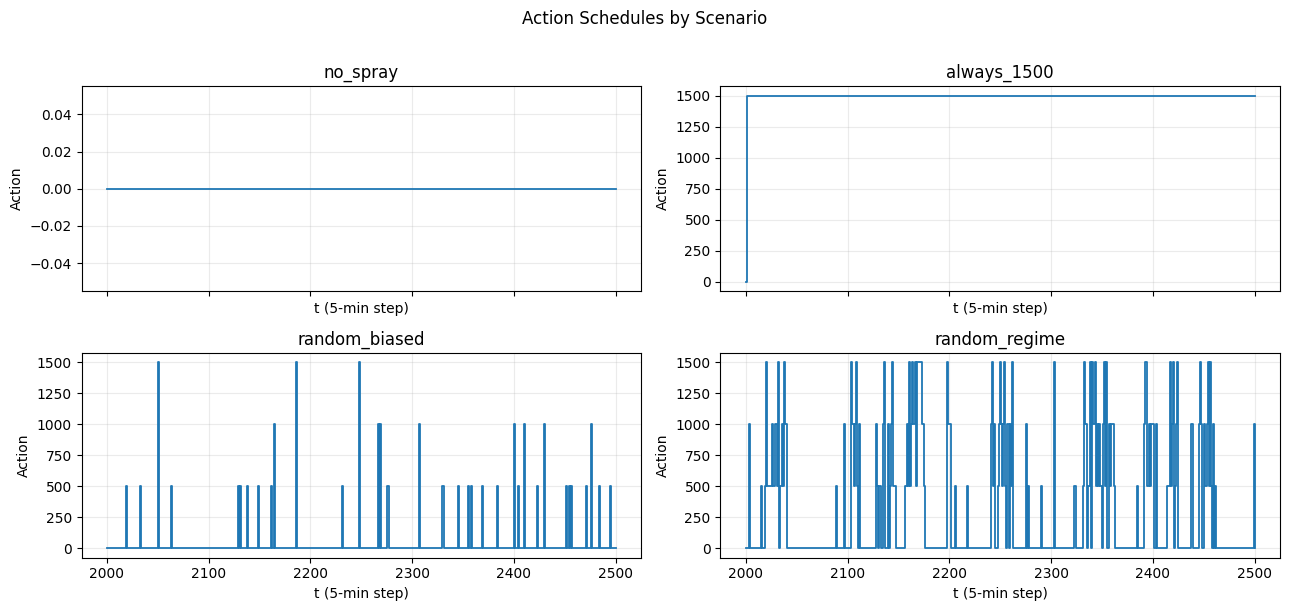

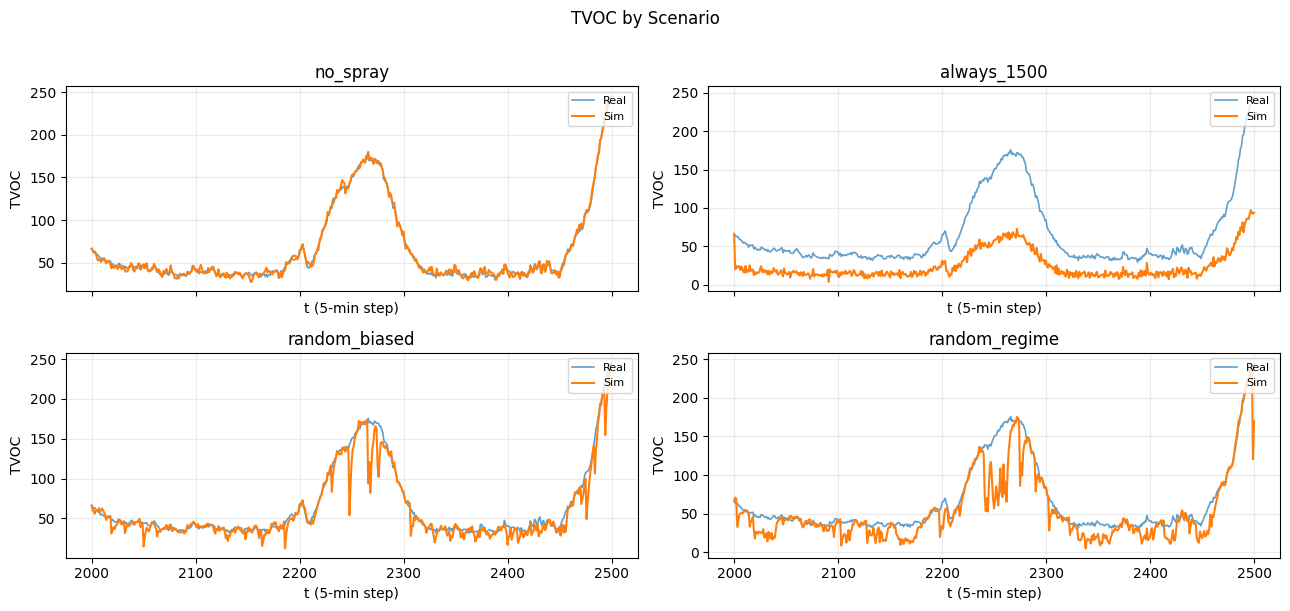

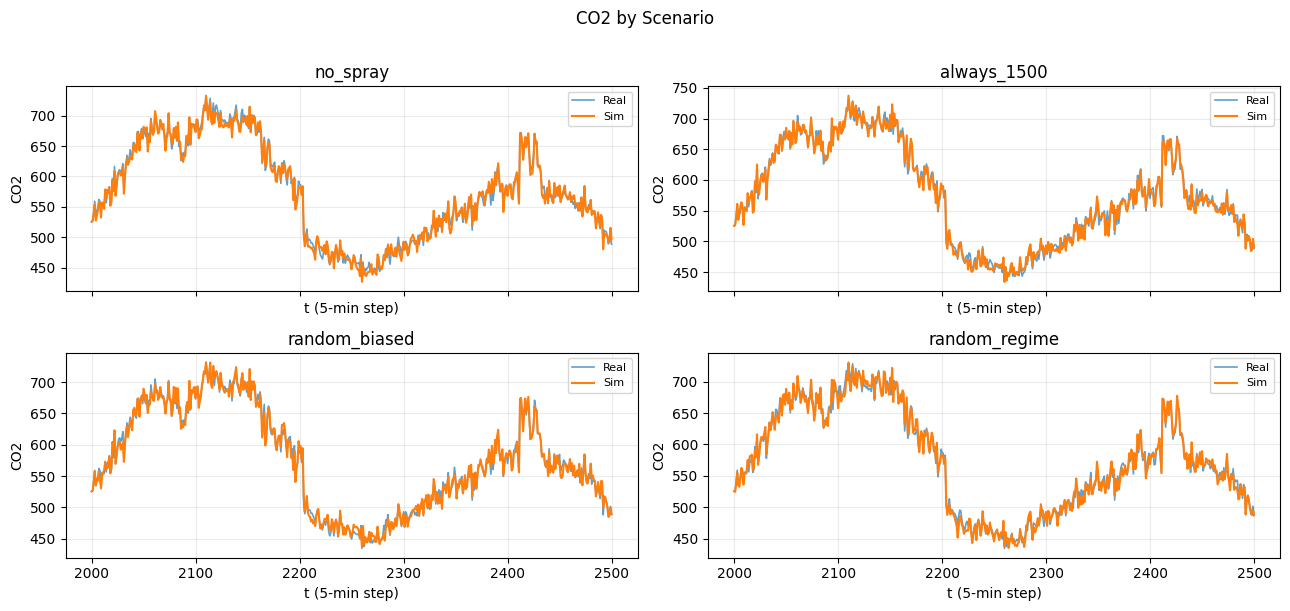

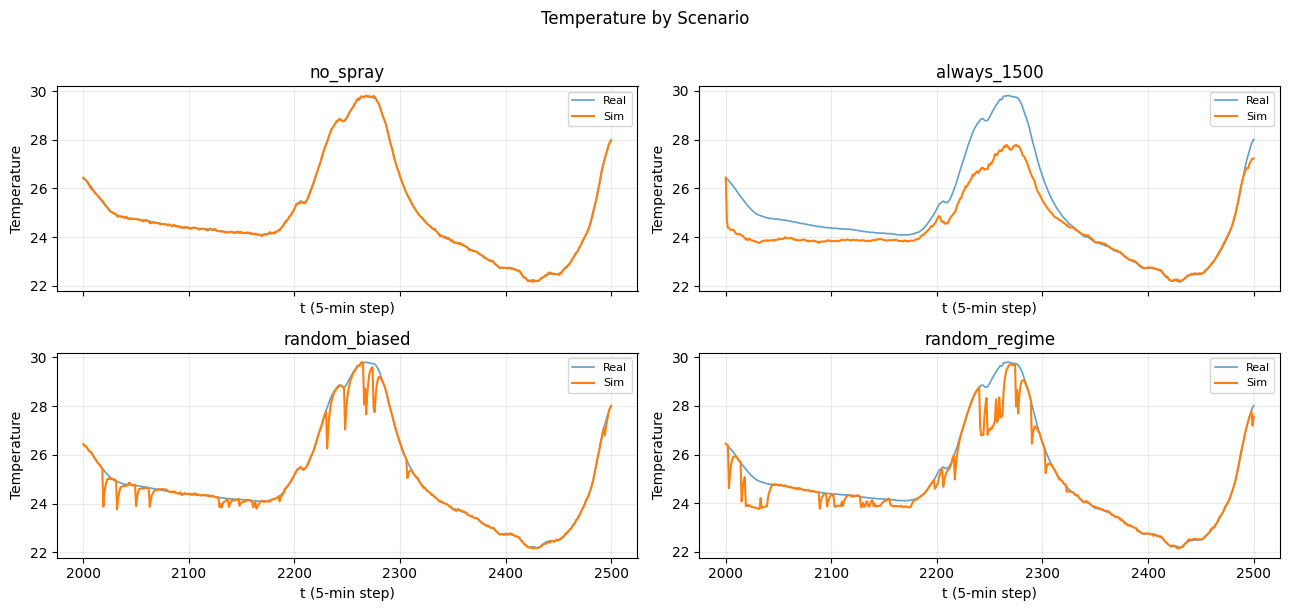

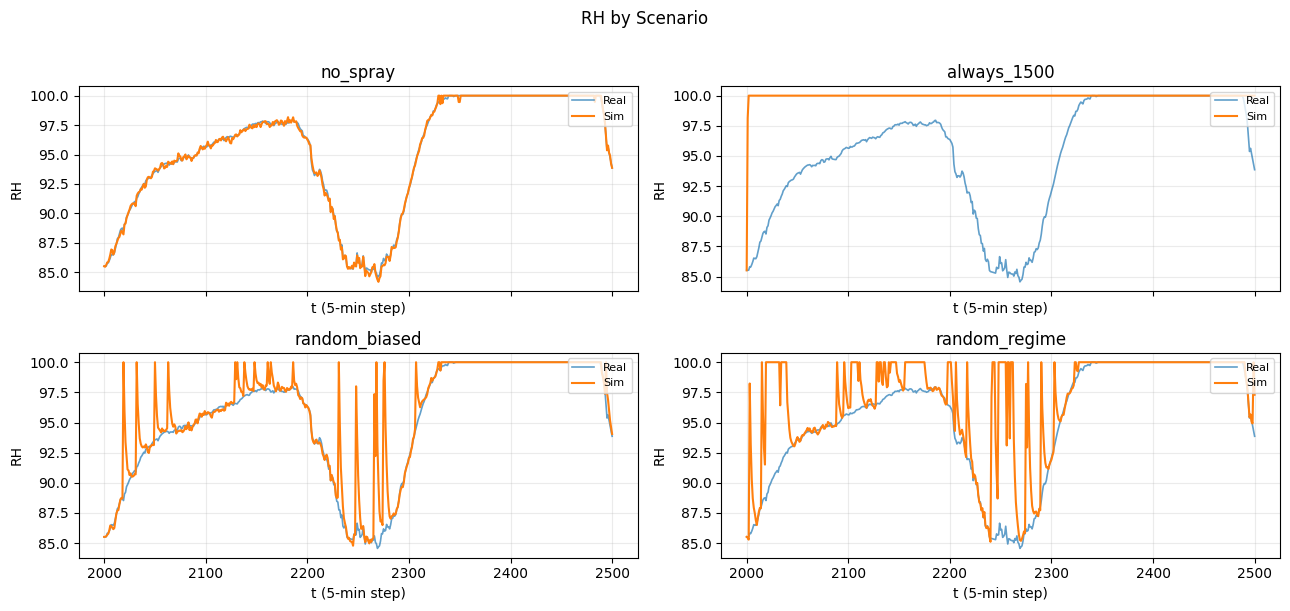

Real-vs-sim MAE by scenario :


,TVOC,CO2,Temp,RH
case,,,,
no_spray,2.203,5.054,0.022,0.108
always_1500,40.613,4.980,0.625,4.741
random_biased,6.220,4.844,0.100,0.684
random_regime,13.126,5.218,0.247,1.813
mean,15.540,5.024,0.248,1.836


            case  steps  tvoc_start    tvoc_end  tvoc_change  \
0       no_spray    500   66.333333  245.192390   178.859057   
1    always_1500    500   66.333333   93.870395    27.537061   
2  random_biased    500   66.333333  240.702263   174.368930   
3  random_regime    500   66.333333  169.451244   103.117910   

   tvoc_mae_vs_real  co2_mae_vs_real  temp_mae_vs_real  rh_mae_vs_real  \
0          2.202632         5.054404          0.021566        0.108283   
1         40.612654         4.979988          0.624607        4.740893   
2          6.220206         4.843733          0.100341        0.683536   
3         13.125856         5.217556          0.246967        1.812896   

    tvoc_min    tvoc_max  
0  27.409902  245.192390  
1   4.031389   97.175352  
2  12.481525  240.702263  
3   5.257441  240.720451  
REWARD TERM BALANCE ANALYSIS

NO_SPRAY:
  Term                    Mean |Contribution|
  ---------------------------------------------
  tvoc_excess           1.2272  ███████

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt

SIM_INPUT_FILE = "pi-1-data-clean-5min.csv"
WEATHER_INPUT_FILE = "thanhhoa_weather-5min.csv"
CASE_SUITE: list[str] = ["no_spray", "always_1500", "random_biased", "random_regime"]
CASE_RUN_STEPS = 500
CASE_RUN_T0 = 2000
CASE_RNG_SEED = 17

base_dir = Path.cwd()
pi1_df = pd.read_csv(base_dir / SIM_INPUT_FILE)
weather_df = pd.read_csv(base_dir / WEATHER_INPUT_FILE)

sim = Pi1SpraySimulator(pi1_df, weather_df)
print(f"Simulator initialized: T={sim.T} steps, action_space={sim.action_space()}")


def make_action_plan(
    case: str,
    steps: int,
    rng: np.random.Generator | None = None,
) -> list[int]:
    """Build categorical action sequence for scenario testing."""
    case_key = case.strip().lower()
    local_rng = rng if rng is not None else np.random.default_rng(CASE_RNG_SEED)

    if case_key in {"no_spray", "none", "case1"}:
        return [0] * steps

    if case_key in {"always_1500", "max", "case2"}:
        return [1500] * steps

    if case_key in {"random_biased", "random", "rare_spray", "case3"}:
        probs = np.array([0.90, 0.06, 0.03, 0.01], dtype=float)
        return local_rng.choice(
            ACTION_CONCENTRATIONS, size=steps, replace=True, p=probs
        ).tolist()

    if case_key in {"random_regime", "regime_switch", "bursty", "case4"}:
        low_probs = np.array([0.96, 0.03, 0.009, 0.001], dtype=float)
        high_probs = np.array([0.20, 0.30, 0.30, 0.20], dtype=float)
        p_stay_low, p_stay_high = 0.97, 0.93
        in_high_regime = bool(local_rng.random() < 0.15)

        sampled: list[int] = []
        for _ in range(steps):
            if in_high_regime:
                sampled.append(
                    int(local_rng.choice(ACTION_CONCENTRATIONS, p=high_probs))
                )
                if local_rng.random() > p_stay_high:
                    in_high_regime = False
            else:
                sampled.append(
                    int(local_rng.choice(ACTION_CONCENTRATIONS, p=low_probs))
                )
                if local_rng.random() > p_stay_low:
                    in_high_regime = True
        return sampled

    raise ValueError("Invalid case")


# --- Scenario suite: run all cases, plot real-vs-sim, collect summary ---

steps = max(2, min(int(CASE_RUN_STEPS), sim.T - 2))
t0 = int(np.clip(CASE_RUN_T0, 0, sim.T - steps - 1))

case_trajectories: dict[str, pd.DataFrame] = {}
real_slices: dict[str, pd.DataFrame] = {}
summary_rows: list[dict] = []

for case in CASE_SUITE:
    actions = make_action_plan(case, steps, rng=sim.rng)
    sim_df = sim.rollout(actions, t0=t0).copy()
    real_df = pd.DataFrame(
        {
            "t": np.arange(t0, t0 + steps + 1),
            "tvoc_real": sim.real_tvoc[t0 : t0 + steps + 1],
            "co2_real": sim.real_co2[t0 : t0 + steps + 1],
            "temp_real": sim.real_temp[t0 : t0 + steps + 1],
            "rh_real": sim.real_rh[t0 : t0 + steps + 1],
        }
    )
    case_trajectories[case] = sim_df
    real_slices[case] = real_df

    merged = sim_df.merge(real_df, on="t", how="left")
    summary_rows.append(
        {
            "case": case,
            "steps": len(sim_df) - 1,
            "tvoc_start": float(sim_df["tvoc"].iloc[0]),
            "tvoc_end": float(sim_df["tvoc"].iloc[-1]),
            "tvoc_change": float(sim_df["tvoc"].iloc[-1])
            - float(sim_df["tvoc"].iloc[0]),
            "tvoc_mae_vs_real": float(
                (merged["tvoc"] - merged["tvoc_real"]).abs().mean()
            ),
            "co2_mae_vs_real": float((merged["co2"] - merged["co2_real"]).abs().mean()),
            "temp_mae_vs_real": float(
                (merged["temp"] - merged["temp_real"]).abs().mean()
            ),
            "rh_mae_vs_real": float((merged["rh"] - merged["rh_real"]).abs().mean()),
            "tvoc_min": float(sim_df["tvoc"].min()),
            "tvoc_max": float(sim_df["tvoc"].max()),
        }
    )

case_summary_df = pd.DataFrame(summary_rows)

# Real-vs-sim MAE table (case x sensor) with per-sensor mean across cases
mae_table = case_summary_df.set_index("case")[
    ["tvoc_mae_vs_real", "co2_mae_vs_real", "temp_mae_vs_real", "rh_mae_vs_real"]
].rename(
    columns={
        "tvoc_mae_vs_real": "TVOC",
        "co2_mae_vs_real": "CO2",
        "temp_mae_vs_real": "Temp",
        "rh_mae_vs_real": "RH",
    }
)
mae_table.loc["mean"] = mae_table.mean(numeric_only=True)

n_cols = 2
n_rows = int(np.ceil(len(CASE_SUITE) / n_cols))

# Action schedules
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.0 * n_rows), sharex=True)
axes_flat = np.atleast_1d(axes).ravel()
for i, case in enumerate(CASE_SUITE):
    axes_flat[i].step(
        case_trajectories[case]["t"],
        case_trajectories[case]["action"],
        where="post",
        linewidth=1.3,
    )
    axes_flat[i].set_title(case)
    axes_flat[i].set_ylabel("Action")
    axes_flat[i].set_xlabel("t (5-min step)")
    axes_flat[i].grid(alpha=0.25)
for j in range(len(CASE_SUITE), len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle("Action Schedules by Scenario", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

# Real vs sim for each sensor
for sim_col, real_col, y_label, title in [
    ("tvoc", "tvoc_real", "TVOC", "TVOC by Scenario"),
    ("co2", "co2_real", "CO2", "CO2 by Scenario"),
    ("temp", "temp_real", "Temperature", "Temperature by Scenario"),
    ("rh", "rh_real", "RH", "RH by Scenario"),
]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.0 * n_rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()
    for i, case in enumerate(CASE_SUITE):
        axes_flat[i].plot(
            real_slices[case]["t"],
            real_slices[case][real_col],
            label="Real",
            alpha=0.7,
            linewidth=1.2,
        )
        axes_flat[i].plot(
            case_trajectories[case]["t"],
            case_trajectories[case][sim_col],
            label="Sim",
            linewidth=1.5,
        )
        axes_flat[i].set_title(case)
        axes_flat[i].set_ylabel(y_label)
        axes_flat[i].set_xlabel("t (5-min step)")
        axes_flat[i].grid(alpha=0.25)
        axes_flat[i].legend(loc="upper right", fontsize=8)
    for j in range(len(CASE_SUITE), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()

print("Real-vs-sim MAE by scenario :")
display(mae_table.round(3))

print(case_summary_df)

# --- Reward term balance analysis ---
scenario_term_stats: dict[str, dict[str, float]] = {}
TERM_KEYS = ["tvoc_excess", "thi", "rh", "cold", "action"]
w_reward = sim.cfg.reward

for case, traj_df in case_trajectories.items():
    accum: dict[str, list[float]] = {k: [] for k in TERM_KEYS}
    for idx in range(len(traj_df) - 1):
        if int(traj_df.loc[idx, "t"]) >= sim.T - 2:
            break
        tvoc_prev = float(traj_df.loc[idx, "tvoc"])
        temp_prev = float(traj_df.loc[idx, "temp"])
        rh_prev = float(traj_df.loc[idx, "rh"])
        tvoc_next = float(traj_df.loc[idx + 1, "tvoc"])
        temp_next = float(traj_df.loc[idx + 1, "temp"])
        rh_next = float(traj_df.loc[idx + 1, "rh"])
        action = int(traj_df.loc[idx + 1, "action"])

        baseline_thi = (
            (0.8 * temp_prev) + ((rh_prev / 100.0) * (temp_prev - 14.4)) + 46.4
        )
        current_thi = (
            (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4
        )
        dose_norm = float(action) / 1500.0

        terms = {
            "tvoc_excess": -max(0.0, tvoc_next - w_reward.tvoc_target)
            / TVOC_EXCESS_NORM,
            "thi": -max(0.0, current_thi - max(73.0, baseline_thi)) / THI_EXCESS_NORM,
            "rh": -max(0.0, rh_next - w_reward.rh_target) / RH_EXCESS_NORM,
            "cold": -max(0.0, 18.0 - temp_next) / COLD_EXCESS_NORM,
            "action": -(
                w_reward.action_curve_alpha_blend * dose_norm
                + (1 - w_reward.action_curve_alpha_blend)
                * dose_norm**w_reward.action_curve_power
            ),
        }
        for k, v in terms.items():
            accum[k].append(abs(v))
    scenario_term_stats[case] = {
        k: float(np.mean(v)) if v else 0.0 for k, v in accum.items()
    }

print("=" * 80)
print("REWARD TERM BALANCE ANALYSIS")
print("=" * 80)
for case, stats in scenario_term_stats.items():
    print(f"\n{case.upper()}:")
    print("  Term                    Mean |Contribution|")
    print("  " + "-" * 45)
    max_val = max(stats.values()) or 1.0
    for term, val in sorted(stats.items(), key=lambda x: -x[1]):
        bar = "█" * int(abs(val) / max_val * 30)
        print(f"  {term:18s}  {val:8.4f}  {bar}")
print("\n" + "=" * 80)


## 5. RL


### Shared RL setup


In [5]:
from __future__ import annotations

import copy
from typing import Literal

import numpy as np
import pandas as pd
import optuna

from dataclasses import dataclass, field

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize


AlgoName = Literal["ppo", "dqn"]


@dataclass(frozen=True)
class RLRunConfig:
    max_steps: int = 288

    # Hyperparameter search
    tune_trials: int = 20
    tune_budget: int = 50_000
    eval_episodes: int = 200  # final per-seed eval (headline numbers)
    tune_eval_episodes: int = 100  # per-Optuna-trial eval (ranking, not CI)
    monitor_eval_episodes: int = 10  # EvalCallback during training (cheap monitoring)

    # Train/eval scaling
    budgets: tuple[int, ...] = (50_000, 100_000, 200_000)
    n_envs: int = 4
    seed: int = 42

    n_train_seeds: int = 3
    eval_seed_stride: int = 100_000

    # Speed
    use_subproc: bool = False  # set True in a script, usually False in notebooks


RUN_CFG = RLRunConfig()

ALGO_CLASSES = {
    "ppo": PPO,
    "dqn": DQN,
}


@dataclass(frozen=True)
class EnvConfig:
    reward: RewardWeights = field(default_factory=RewardWeights)
    max_steps: int = 288
    gamma: float = 0.99
    tvoc_norm_divisor: float = 494.6483
    co2_norm_divisor: float = 1536.9867
    temp_norm_divisor: float = 35.2306
    rh_min: float = 64.3650
    rh_span: float = 35.6350


class Pi1SprayEnv(gym.Env):
    """Gymnasium-compliant environment for deodorization spray control."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        simulator: Pi1SpraySimulator,
        config: EnvConfig | None = None,
    ) -> None:
        self.sim = simulator
        self.cfg = config

        # Action space: categorical [0, 500, 1000, 1500]
        self.action_to_concentration = {
            idx: concentration
            for idx, concentration in enumerate(ACTION_CONCENTRATIONS)
        }
        self.action_space = spaces.Discrete(len(self.action_to_concentration))

        # Observation: [tvoc_norm, co2_norm, temp_norm, rh_norm]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.t: int = 0
        self.steps_taken: int = 0

    def reset(
        self, seed: int | None = None, options: dict | None = None
    ) -> tuple[np.ndarray, dict]:
        super().reset(seed=seed)
        _ = options
        start_t = self.np_random.integers(0, max(1, self.sim.T - self.cfg.max_steps))
        self.t = start_t
        self.state = self.sim.reset(t0=start_t).astype(np.float32)
        self.steps_taken = 0

        obs = self._build_obs(self.state)
        return obs, {}

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        dose = self.action_to_concentration[int(action)]
        state_prev = self.state.copy()
        next_state = self.sim.step(state_prev, dose, self.t).astype(np.float32)

        self.state = next_state
        self.t += 1
        self.steps_taken += 1

        terminated = self.t >= self.sim.T - 2
        truncated = self.steps_taken >= self.cfg.max_steps
        is_terminal = terminated or truncated

        reward = self.sim.compute_reward(
            tvoc_prev=float(state_prev[0]),
            tvoc_next=float(next_state[0]),
            temp_prev=float(state_prev[2]),
            temp_next=float(next_state[2]),
            rh_prev=float(state_prev[3]),
            rh_next=float(next_state[3]),
            action=dose,
            reward_weights=self.cfg.reward,
            is_terminal=is_terminal,
        )

        info = {
            "tvoc": float(self.state[0]),
            "co2": float(self.state[1]),
            "temp": float(self.state[2]),
            "rh": float(self.state[3]),
            "dose": dose,
        }

        obs = self._build_obs(self.state)
        return obs, reward, terminated, truncated, info

    def _build_obs(self, s: np.ndarray) -> np.ndarray:
        return np.array(
            [
                s[0] / self.cfg.tvoc_norm_divisor,
                s[1] / self.cfg.co2_norm_divisor,
                s[2] / self.cfg.temp_norm_divisor,
                (s[3] - self.cfg.rh_min) / self.cfg.rh_span,
            ],
            dtype=np.float32,
        )

### Environment builders, hyperparameter search, and model construction.


In [6]:
def make_env_fn(base_sim, env_cfg: EnvConfig, seed: int, rank: int):
    def _init():
        sim_i = copy.deepcopy(base_sim)
        sim_i.rng = np.random.default_rng(seed + 10_000 * rank)
        env = Pi1SprayEnv(sim_i, config=env_cfg)
        return Monitor(env)

    return _init


def build_vec_env(
    base_sim,
    env_cfg: EnvConfig,
    seed: int,
    n_envs: int,
    normalize: bool = True,
    use_subproc: bool = False,
    gamma: float = 0.99,
):
    vec_cls = SubprocVecEnv if use_subproc else DummyVecEnv

    env_fns = [make_env_fn(base_sim, env_cfg, seed, rank) for rank in range(n_envs)]
    vec_env = vec_cls(env_fns)

    if normalize:
        vec_env = VecNormalize(
            vec_env,
            norm_obs=True,
            norm_reward=True,
            clip_obs=10.0,
            clip_reward=10.0,
            gamma=gamma,
        )
    return vec_env


def sample_hyperparams(algo: AlgoName, trial: optuna.Trial) -> dict:
    if algo == "ppo":
        # Optuna complains about tuples not suitable for persistent storage
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-4, log=True),
            "n_steps": trial.suggest_categorical("n_steps", [64, 128, 256]),
            "batch_size": trial.suggest_categorical("batch_size", [64, 128]),
            "n_epochs": trial.suggest_categorical("n_epochs", [5, 10]),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "gae_lambda": trial.suggest_float("gae_lambda", 0.90, 0.98),
            "clip_range": trial.suggest_float("clip_range", 0.10, 0.30),
            "ent_coef": trial.suggest_float("ent_coef", 5e-3, 5e-2, log=True),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    if algo == "dqn":
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
            "buffer_size": trial.suggest_categorical(
                "buffer_size", [50_000, 100_000, 200_000]
            ),
            "learning_starts": trial.suggest_categorical(
                "learning_starts", [1_000, 5_000, 10_000]
            ),
            "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
            "train_freq": trial.suggest_categorical("train_freq", [1, 4]),
            "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 4]),
            "target_update_interval": trial.suggest_categorical(
                "target_update_interval", [250, 500, 1000]
            ),
            "exploration_fraction": trial.suggest_float(
                "exploration_fraction", 0.05, 0.30
            ),
            "exploration_final_eps": trial.suggest_float(
                "exploration_final_eps", 0.01, 0.10
            ),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    raise ValueError(f"Unknown algo: {algo}")


### Evaluation, tuning, and budget sweep.


In [ ]:
from stable_baselines3.common.callbacks import EvalCallback


def evaluate_model(
    model,
    eval_env,
    env_cfg: EnvConfig,
    n_episodes: int,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Run deterministic evaluation episodes and collect metrics for analysis.
    An "episode" here is a single trajectory until termination or max_steps, not a fixed number of steps. n_episodes controls the granularity of reward statistics and action distribution, but the total number of steps may vary based on episode lengths.
    """
    reward_list: list[float] = []
    tvoc_delta_list: list[float] = []
    rh_excess_list: list[float] = []
    co2_list: list[float] = []
    temp_list: list[float] = []
    action_counts = {dose: 0 for dose in ACTION_CONCENTRATIONS}
    step_tvoc_hit = 0
    step_count = 0

    for ep in range(n_episodes):
        eval_env.seed(seed + ep)
        obs = eval_env.reset()

        # Raw initial state is stored inside the wrapped env.
        tvoc_start = float(eval_env.get_attr("state")[0][0])

        ep_reward = 0.0
        done = [False]

        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, rewards, done, infos = eval_env.step(action)

            ep_reward += float(rewards[0])
            info = infos[0]

            dose = int(info["dose"])
            action_counts[dose] += 1

            tvoc = float(info["tvoc"])
            co2 = float(info["co2"])
            temp = float(info["temp"])
            rh = float(info["rh"])

            tvoc_delta_list.append(tvoc - tvoc_start)
            rh_excess_list.append(max(0.0, rh - env_cfg.reward.rh_target))
            co2_list.append(co2)
            temp_list.append(temp)

            if tvoc <= env_cfg.reward.tvoc_target:
                step_tvoc_hit += 1
            step_count += 1

        reward_list.append(ep_reward)

    total_actions = max(1, sum(action_counts.values()))
    action_ratio = {
        f"concentration_{dose}_ratio": action_counts[dose] / total_actions
        for dose in ACTION_CONCENTRATIONS
    }
    action_probs = np.array(
        [action_counts[d] / total_actions for d in ACTION_CONCENTRATIONS], dtype=float
    )
    action_entropy = float(
        -(action_probs[action_probs > 0] * np.log(action_probs[action_probs > 0])).sum()
    )
    dominant_action_ratio = float(action_probs.max())

    out = {
        "episodes": n_episodes,
        "reward_mean": float(np.mean(reward_list)),
        "reward_episode_std": float(np.std(reward_list)),
        "reward_seed_std": float(np.std(reward_list)),
        "tvoc_delta_mean": float(np.mean(tvoc_delta_list))
        if tvoc_delta_list
        else np.nan,
        "tvoc_delta_std": float(np.std(tvoc_delta_list)) if tvoc_delta_list else np.nan,
        "mean_rh_excess": float(np.mean(rh_excess_list)) if rh_excess_list else np.nan,
        "mean_co2": float(np.mean(co2_list)) if co2_list else np.nan,
        "mean_temp": float(np.mean(temp_list)) if temp_list else np.nan,
        "tvoc_target_hit_rate": step_tvoc_hit / max(1, step_count),
        "action_entropy": action_entropy,
        "dominant_action_ratio": dominant_action_ratio,
        "episode_rewards": np.asarray(reward_list, dtype=float),
        **action_ratio,
    }
    return pd.DataFrame([out])


def tune_hyperparams(
    algo: AlgoName,
    base_sim,
    run_cfg: RLRunConfig = RUN_CFG,
    plot_study: bool = True,
) -> dict:
    def objective(trial: optuna.Trial) -> float:
        params = sample_hyperparams(algo, trial)
        gamma = float(params.get("gamma", 0.99))
        env_cfg = EnvConfig(
            reward=base_sim.cfg.reward,
            max_steps=RUN_CFG.max_steps,
            gamma=gamma,
        )

        train_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=run_cfg.seed + trial.number * 1000,
            n_envs=run_cfg.n_envs,
            normalize=True,
            use_subproc=run_cfg.use_subproc,
            gamma=gamma,
        )

        model = ALGO_CLASSES[algo](
            policy="MlpPolicy",
            env=train_env,
            seed=run_cfg.seed + trial.number,
            device="cpu",
            verbose=0,
            **params,
        )
        model.learn(total_timesteps=run_cfg.tune_budget)

        # Build eval env (VecNormalize stats get auto-synced by EvalCallback;
        # here we only set the eval-mode flags since the callback doesn't touch them)
        eval_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=run_cfg.seed + 50_000 + trial.number,
            n_envs=1,
            normalize=True,
            use_subproc=False,
            gamma=env_cfg.gamma,
        )
        eval_env.training = False
        eval_env.norm_reward = False

        metrics = evaluate_model(
            model=model,
            eval_env=eval_env,
            env_cfg=env_cfg,
            n_episodes=run_cfg.tune_eval_episodes,
            seed=run_cfg.seed + 100_000 + trial.number,
        )

        train_env.close()
        eval_env.close()
        return float(metrics.loc[0, "reward_mean"])

    sampler = optuna.samplers.TPESampler(seed=run_cfg.seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=run_cfg.tune_trials, show_progress_bar=True)

    # Convert Optuna's flat "net_arch" string back into policy_kwargs form
    best = dict(study.best_params)
    if "net_arch" in best:
        raw = best.pop("net_arch")
        net_arch = (
            tuple(int(x) for x in raw.split(","))
            if isinstance(raw, str)
            else tuple(raw)
        )
        best["policy_kwargs"] = {"net_arch": list(net_arch)}

    if plot_study:

        def _try_plot_optuna(fig, width: int = 900, height: int = 500):
            if fig is None:
                return
            try:
                fig.update_layout(width=width, height=height)
                fig.show()
            except Exception as e:
                print(f"Skipping Optuna plot render: {e}")

        print(f"\nOptuna tuning summary for {algo.upper()}:")
        print(f"  trials={len(study.trials)}  best_value={study.best_value:.4f}")
        print(f"  best_params={study.best_params}")

        try:
            from optuna.visualization import (
                plot_optimization_history,
                plot_param_importances,
                plot_parallel_coordinate,
                plot_slice,
            )

            _try_plot_optuna(plot_optimization_history(study), width=920, height=420)
            _try_plot_optuna(plot_param_importances(study), width=920, height=500)
            _try_plot_optuna(plot_parallel_coordinate(study), width=980, height=520)
            _try_plot_optuna(plot_slice(study), width=980, height=520)
        except Exception as e:
            print(f"Optuna visualization is unavailable: {e}")
            print("Install/upgrade with: pip install optuna[visualization] plotly")

    return best


# For statistical significance testing, we want to compare per-episode rewards across policies with a paired test (e.g. Wilcoxon signed-rank) to control for stochasticity in episode generation. To do that, we need to run a final evaluation pass at the same seed across all policies to get aligned episode rewards.
# Sharing this seed means episode i across all policies is initialized from the same stochastic realization, which makes paired hypothesis tests valid.
SIGNIFICANCE_EVAL_SEED = 42
SIGNIFICANCE_EVAL_EPISODES = 200


def train_one_budget(
    algo: AlgoName,
    base_sim,
    env_cfg: EnvConfig,
    params: dict,
    total_timesteps: int,
    run_cfg: RLRunConfig = RUN_CFG,
):
    seed_metrics = []
    aligned_episode_rewards = None  # filled on the final training seed

    for seed_offset in range(run_cfg.n_train_seeds):
        seed = run_cfg.seed + seed_offset * run_cfg.eval_seed_stride
        is_last_seed = seed_offset == run_cfg.n_train_seeds - 1

        train_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=seed,
            n_envs=run_cfg.n_envs,
            normalize=True,
            use_subproc=run_cfg.use_subproc,
            gamma=params.get("gamma", 0.99),
        )

        # Build eval env (EvalCallback auto-syncs obs_rms/ret_rms from train_env
        # before every callback eval on SB3 >= 1.8, so only the flags matter here)
        eval_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=seed + 999,
            n_envs=1,
            normalize=True,
            use_subproc=False,
            gamma=env_cfg.gamma,
        )
        eval_env.training = False
        eval_env.norm_reward = False

        eval_callback = EvalCallback(
            eval_env,
            eval_freq=max(1, 5_000 // run_cfg.n_envs),
            n_eval_episodes=run_cfg.monitor_eval_episodes,
            deterministic=True,
            verbose=0,
        )

        # Build model (inlined)
        model = ALGO_CLASSES[algo](
            policy="MlpPolicy",
            env=train_env,
            seed=seed,
            device="cpu",
            verbose=0,
            **params,
        )
        model.learn(total_timesteps=total_timesteps, callback=eval_callback)

        # Final evaluate_model call below bypasses EvalCallback, so we have to
        # manually copy the post-training VecNormalize stats over here
        eval_env.obs_rms = copy.deepcopy(train_env.obs_rms)
        eval_env.ret_rms = copy.deepcopy(train_env.ret_rms)
        eval_env.training = False
        eval_env.norm_reward = False

        metrics = evaluate_model(
            model=model,
            eval_env=eval_env,
            env_cfg=env_cfg,
            n_episodes=run_cfg.eval_episodes,
            seed=seed + 1_000,
        )
        metrics["train_seed"] = seed
        seed_metrics.append(metrics)

        # On the final training seed, also run an evaluation pass at the same seed scheme used by the baseline evaluators (cell 15) so per-episode rewards can be compared pairwise for statistical-significance testing.
        if is_last_seed:
            aligned_metrics = evaluate_model(
                model=model,
                eval_env=eval_env,
                env_cfg=env_cfg,
                n_episodes=SIGNIFICANCE_EVAL_EPISODES,
                seed=SIGNIFICANCE_EVAL_SEED,
            )
            aligned_episode_rewards = np.asarray(
                aligned_metrics.loc[0, "episode_rewards"], dtype=float
            )

        train_env.close()
        eval_env.close()

    combined = pd.concat(seed_metrics, ignore_index=True)
    agg = combined.mean(numeric_only=True).to_frame().T
    agg["reward_seed_std"] = combined[
        "reward_mean"
    ].std()  # std across seeds, not within
    agg["algo"] = algo
    agg["timesteps"] = total_timesteps
    # Per-episode rewards from the seed-aligned eval (200 episodes at seed=42),
    # used for significance-testing (run paired Wilcoxon vs baselines)
    agg["aligned_episode_rewards"] = [aligned_episode_rewards]
    return model, agg  # returns last model; main value is aggregated metrics


### Run tuning once per algorithm, then sweep multiple budgets.


In [9]:
import json

sim = Pi1SpraySimulator(
    pd.read_csv("pi-1-data-clean-5min.csv"),
    pd.read_csv("thanhhoa_weather-5min.csv"),
)

algorithms_to_run = ("ppo", "dqn")
best_params_by_algo: dict[str, dict] = {}

for algo in algorithms_to_run:
    print(f"\nTuning {algo.upper()} ...")
    best_params = tune_hyperparams(algo, sim, RUN_CFG)
    best_params_by_algo[algo] = best_params
    print(f"Best {algo.upper()} params:\n{best_params}")

print("Summarize of best hyperparameters found:")
for algo, params in best_params_by_algo.items():
    print(f"{algo.upper()}: {params}")

with open("best_params.json", "w") as f:
    json.dump(best_params_by_algo, f, indent=4)

[I 2026-05-18 10:32:15,124] A new study created in memory with name: no-name-e92e0455-967b-4fe5-83fb-172972216bcb



Tuning PPO ...


Best trial: 0. Best value: -585.475:   5%|▌         | 1/20 [00:18<05:46, 18.24s/it]

[I 2026-05-18 10:32:33,370] Trial 0 finished with value: -585.47457252869 and parameters: {'net_arch': '128,128', 'learning_rate': 7.661100707771373e-05, 'n_steps': 64, 'batch_size': 64, 'n_epochs': 5, 'gamma': 0.9983985016228836, 'gae_lambda': 0.9665954112640337, 'clip_range': 0.14246782213565523, 'ent_coef': 0.007599674150654906}. Best is trial 0 with value: -585.47457252869.


Best trial: 0. Best value: -585.475:  10%|█         | 2/20 [00:36<05:31, 18.40s/it]

...

Best trial: 9. Best value: -547.702:  95%|█████████▌| 19/20 [08:42<00:27, 27.58s/it]

[I 2026-05-18 10:46:46,618] Trial 18 finished with value: -604.6112899611232 and parameters: {'net_arch': '64,64', 'learning_rate': 8.629897610399965e-05, 'buffer_size': 100000, 'learning_starts': 10000, 'batch_size': 64, 'train_freq': 4, 'gradient_steps': 1, 'target_update_interval': 1000, 'exploration_fraction': 0.2631994284646849, 'exploration_final_eps': 0.0660561886342347, 'gamma': 0.9714649118710799}. Best is trial 9 with value: -547.7016247094512.


Best trial: 9. Best value: -547.702: 100%|██████████| 20/20 [09:22<00:00, 28.13s/it]

[I 2026-05-18 10:47:26,929] Trial 19 finished with value: -648.83720472467 and parameters: {'net_arch': '128,128', 'learning_rate': 4.303415874647651e-05, 'buffer_size': 200000, 'learning_starts': 5000, 'batch_size': 32, 'train_freq': 1, 'gradient_steps': 4, 'target_update_interval': 250, 'exploration_fraction': 0.05942064429911727, 'exploration_final_eps': 0.03053319447826688, 'gamma': 0.9600100318113881}. Best is trial 9 with value: -547.7016247094512.

Optuna tuning summary for DQN:
  trials=20  best_value=-547.7016
  best_params={'net_arch': '64,64', 'learning_rate': 0.00012516058337570362, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 128, 'train_freq': 1, 'gradient_steps': 4, 'target_update_interval': 1000, 'exploration_fraction': 0.1482744311666901, 'exploration_final_eps': 0.0902841899659402, 'gamma': 0.9814938174372634}


Best DQN params:
{'learning_rate': 0.00012516058337570362, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 128, 'train_freq': 1, 'gradient_steps': 4, 'target_update_interval': 1000, 'exploration_fraction': 0.1482744311666901, 'exploration_final_eps': 0.0902841899659402, 'gamma': 0.9814938174372634, 'policy_kwargs': {'net_arch': [64, 64]}}
Summarize of best hyperparameters found:
PPO: {'learning_rate': 0.00015292012157885936, 'n_steps': 256, 'batch_size': 128, 'n_epochs': 5, 'gamma': 0.9952924732845977, 'gae_lambda': 0.9776988454858332, 'clip_range': 0.15781185191674718, 'ent_coef': 0.005456699991654547, 'policy_kwargs': {'net_arch': [128, 128]}}
DQN: {'learning_rate': 0.00012516058337570362, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 128, 'train_freq': 1, 'gradient_steps': 4, 'target_update_interval': 1000, 'exploration_fraction': 0.1482744311666901, 'exploration_final_eps': 0.0902841899659402, 'gamma': 0.9814938174372634, 'policy_kwargs': {'net_arch': [6

In [ ]:
import json
import copy

sim = Pi1SpraySimulator(
    pd.read_csv("pi-1-data-clean-5min.csv"),
    pd.read_csv("thanhhoa_weather-5min.csv"),
)

with open("best_params.json") as f:
    best_params_by_algo = json.load(f)
gamma = float(best_params_by_algo["ppo"].get("gamma", 0.99))
env_cfg_baseline = EnvConfig(
    reward=sim.cfg.reward,
    max_steps=RUN_CFG.max_steps,
    gamma=gamma,
)


def evaluate_fixed_policy(base_sim, env_cfg, action_idx, n_episodes=200, seed=42):
    """Evaluate a policy that always takes the same discrete action."""
    rewards = []
    for ep in range(n_episodes):
        sim_i = copy.deepcopy(base_sim)
        sim_i.rng = np.random.default_rng(seed + ep)
        env = Pi1SprayEnv(sim_i, config=env_cfg)
        obs, _ = env.reset(seed=seed + ep)
        ep_reward, done = 0.0, False
        while not done:
            obs, r, terminated, truncated, _ = env.step(action_idx)
            ep_reward += r
            done = terminated or truncated
        rewards.append(ep_reward)
    rewards_arr = np.asarray(rewards, dtype=float)
    return float(rewards_arr.mean()), float(rewards_arr.std()), rewards_arr


def evaluate_threshold_policy(
    base_sim, env_cfg, tvoc_threshold=60.0, spray_dose_idx=3, n_episodes=200, seed=42
):
    """Spray at max dose when TVOC > threshold, else do nothing."""
    rewards = []
    actions = []
    for ep in range(n_episodes):
        sim_i = copy.deepcopy(base_sim)
        sim_i.rng = np.random.default_rng(seed + ep)
        env = Pi1SprayEnv(sim_i, config=env_cfg)
        obs, _ = env.reset(seed=seed + ep)
        ep_reward, done = 0.0, False
        while not done:
            tvoc = float(env.state[0])
            action = spray_dose_idx if tvoc > tvoc_threshold else 0
            actions.append(action)
            obs, r, terminated, truncated, _ = env.step(action)
            ep_reward += r
            done = terminated or truncated
        rewards.append(ep_reward)
    rewards_arr = np.asarray(rewards, dtype=float)
    return float(rewards_arr.mean()), float(rewards_arr.std()), actions, rewards_arr


# Stash per-episode rewards for significance-testing
baseline_episode_rewards: dict[str, np.ndarray] = {}

print("Fixed-policy baselines (mean ± std over 200 episodes):")
for action_idx, label in enumerate(
    ["no_spray", "always_500", "always_1000", "always_1500"]
):
    mean, std, rewards_arr = evaluate_fixed_policy(sim, env_cfg_baseline, action_idx)
    baseline_episode_rewards[label] = rewards_arr
    print(
        f"  {label:15s}: {mean:8.1f} ± {std:<8.1f} (non-action ratio: {1.0 if action_idx == 0 else 0.0:.2f})"
    )

print("\nThreshold policies:")
for threshold in [20, 35, 50, 65, 80, 100]:
    for dose_idx, dose_label in [(1, "500"), (2, "1000"), (3, "1500")]:
        mean, std, actions, rewards_arr = evaluate_threshold_policy(
            sim, env_cfg_baseline, tvoc_threshold=threshold, spray_dose_idx=dose_idx
        )
        label = f"thresh_{threshold}_{dose_label}"
        baseline_episode_rewards[label] = rewards_arr
        print(
            f"  {label:18s}: {mean:8.1f} ± {std:<8.1f} (non-action ratio: {np.mean(np.array(actions) == 0):.2f})"
        )


Fixed-policy baselines (mean ± std over 200 episodes):
  no_spray       :  -1542.5 ± 1487.8   (non-action ratio: 1.00)
  always_500     :   -775.7 ± 814.3    (non-action ratio: 0.00)
  always_1000    :   -624.1 ± 593.6    (non-action ratio: 0.00)
  always_1500    :   -642.6 ± 487.5    (non-action ratio: 0.00)

Threshold policies:
  thresh_20_500     :   -781.3 ± 811.5    (non-action ratio: 0.04)
  thresh_20_1000    :   -630.3 ± 589.4    (non-action ratio: 0.10)
  thresh_20_1500    :   -636.8 ± 487.0    (non-action ratio: 0.14)
  thresh_35_500     :   -797.1 ± 803.9    (non-action ratio: 0.18)
  thresh_35_1000    :   -639.6 ± 587.2    (non-action ratio: 0.25)
  thresh_35_1500    :   -631.9 ± 491.9    (non-action ratio: 0.31)
  thresh_50_500     :   -798.9 ± 808.3    (non-action ratio: 0.31)
  thresh_50_1000    :   -644.5 ± 592.2    (non-action ratio: 0.40)
  thresh_50_1500    :   -637.8 ± 496.8    (non-action ratio: 0.46)
  thresh_65_500     :   -832.2 ± 801.2    (non-action ratio: 0.42

In [ ]:
import json

sim = Pi1SpraySimulator(
    pd.read_csv("pi-1-data-clean-5min.csv"),
    pd.read_csv("thanhhoa_weather-5min.csv"),
)
algorithms_to_run = ("ppo", "dqn")

with open("best_params.json", "r") as f:
    best_params_by_algo = json.load(f)

all_rows: list[pd.DataFrame] = []
rl_episode_rewards: dict[tuple[str, int], np.ndarray] = {}

for algo in algorithms_to_run:
    best_params = best_params_by_algo[algo]
    if "net_arch" in best_params and isinstance(best_params["net_arch"], str):
        best_params["policy_kwargs"] = {
            "net_arch": [int(x) for x in best_params["net_arch"].split(",")]
        }
    gamma = float(best_params.get("gamma", 0.99))
    env_cfg = EnvConfig(
        reward=sim.cfg.reward,
        max_steps=RUN_CFG.max_steps,
        gamma=gamma,
    )

    for budget in RUN_CFG.budgets:
        print(f"\nTraining {algo.upper()} for {budget:,} timesteps ...")
        _, metrics = train_one_budget(
            algo=algo,
            base_sim=sim,
            env_cfg=env_cfg,
            params=best_params,
            total_timesteps=budget,
            run_cfg=RUN_CFG,
        )
        metrics.insert(0, "gamma", gamma)
        # Pull per-episode rewards (seed-aligned with baselines) out of the row before dropping the column from the displayed/aggregated table
        aligned = metrics.loc[0, "aligned_episode_rewards"]
        if aligned is not None:
            rl_episode_rewards[(algo, int(budget))] = np.asarray(aligned, dtype=float)
        metrics_display = metrics.drop(columns=["aligned_episode_rewards"])
        all_rows.append(metrics_display)
        print(metrics_display.to_string(index=False))

results_df = pd.concat(all_rows, ignore_index=True)
results_df = results_df.sort_values(["algo", "timesteps"]).reset_index(drop=True)
results_df



Training PPO for 50,000 timesteps ...
   gamma  episodes  reward_mean  reward_episode_std  reward_seed_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess   mean_co2  mean_temp  tvoc_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration_1000_ratio  concentration_1500_ratio  train_seed algo  timesteps
0.995292     200.0  -646.942682          632.544836       129.901545       -88.495433      111.380337        9.297828 590.060803  25.578457              0.539326        0.663012               0.744419                 0.0725                 0.012587                  0.422184                  0.492729    100042.0  ppo      50000

Training PPO for 100,000 timesteps ...
   gamma  episodes  reward_mean  reward_episode_std  reward_seed_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess   mean_co2  mean_temp  tvoc_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration

,gamma,episodes,reward_mean,reward_episode_std,reward_seed_std,tvoc_delta_mean,tvoc_delta_std,mean_rh_excess,mean_co2,mean_temp,tvoc_target_hit_rate,action_entropy,dominant_action_ratio,concentration_0_ratio,concentration_500_ratio,concentration_1000_ratio,concentration_1500_ratio,train_seed,algo,timesteps
0,0.981607,200.0,-599.938922,510.510003,66.421222,-86.042709,109.789669,8.472126,590.060803,25.743603,0.467965,1.171400,0.481948,0.196899,0.108397,0.393146,0.301558,100042.0,dqn,50000
1,0.981607,200.0,-591.484649,541.957873,33.688621,-86.270367,111.091153,8.254821,590.130649,25.753760,0.470830,1.016033,0.511582,0.269897,0.041030,0.208498,0.480575,100042.0,dqn,100000
2,0.981607,200.0,-570.954133,522.748798,45.388521,-85.759846,109.830139,8.331229,590.087958,25.716706,0.454337,1.182803,0.433492,0.297241,0.094537,0.183577,0.424644,100042.0,dqn,200000
3,0.995292,200.0,-646.942682,632.544836,129.901545,-88.495433,111.380337,9.297828,590.060803,25.578457,0.539326,0.663012,0.744419,0.072500,0.012587,0.422184,0.492729,100042.0,ppo,50000
4,0.995292,200.0,-613.137121,573.367744,46.215809,-89.728155,109.213312,9.215089,590.130649,25.578795,0.532636,0.838858,0.696520,0.102217,0.022760,0.331321,0.543701,100042.0,ppo,100000
5,0.995292,200.0,-624.349566,578.948094,18.464980,-91.959681,108.994836,9.372518,590.087958,25.545104,0.561594,0.764252,0.659141,0.085180,0.018085,0.237594,0.659141,100042.0,ppo,200000


### Statistical significance vs baseline policies

Paired Wilcoxon signed-rank test (one-sided, alt: RL > baseline) on per-episode rewards collected at a shared seed (`SIGNIFICANCE_EVAL_SEED=42`, 200 episodes), so episode `i` of the RL run corresponds to the same simulator stochastic realization as episode `i` of every baseline. p-values are Holm-Bonferroni corrected across the full grid of `(algo, budget) * baseline` comparisons. Effect size reported as rank-biserial _r_ (approx 1 -> RL almost always wins, 0 -> ties, −1 -> baseline almost always wins).


In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

# every reward vector must be the same length (paired test prerequisite)
n_ep = SIGNIFICANCE_EVAL_EPISODES
for name, arr in baseline_episode_rewards.items():
    assert len(arr) == n_ep, (
        f"baseline {name!r} has {len(arr)} episodes, expected {n_ep}"
    )
for key, arr in rl_episode_rewards.items():
    assert len(arr) == n_ep, f"RL {key!r} has {len(arr)} episodes, expected {n_ep}"
print(
    f"Paired sample size n={n_ep} | baselines={len(baseline_episode_rewards)} | "
    f"RL points={len(rl_episode_rewards)} | tests={len(baseline_episode_rewards) * len(rl_episode_rewards)}"
)


def _wilcoxon_one_sided_greater(diff: np.ndarray) -> tuple[float, float, float, float]:
    """Run paired Wilcoxon (H1: median(diff) > 0) and return (p, r, W_plus, W_minus).

    Rank-biserial r = (W_plus - W_minus) / (W_plus + W_minus); positive favors RL.
    Zeros are dropped (Wilcoxon zero_method="wilcox"). Returns p=1.0 if all-zero.
    """
    nz = diff[diff != 0.0]
    if nz.size == 0:
        return 1.0, 0.0, 0.0, 0.0
    ranks = stats.rankdata(np.abs(nz))
    w_plus = float(ranks[nz > 0].sum())
    w_minus = float(ranks[nz < 0].sum())
    denom = w_plus + w_minus
    r_eff = (w_plus - w_minus) / denom if denom > 0 else 0.0
    res = stats.wilcoxon(diff, alternative="greater", zero_method="wilcox")
    return float(res.pvalue), float(r_eff), w_plus, w_minus


rows: list[dict] = []
for (algo, budget), rl_arr in rl_episode_rewards.items():
    for baseline_name, base_arr in baseline_episode_rewards.items():
        diff = rl_arr - base_arr
        p_raw, r_eff, _, _ = _wilcoxon_one_sided_greater(diff)
        rows.append(
            {
                "algo": algo,
                "budget": int(budget),
                "baseline": baseline_name,
                "rl_mean": float(rl_arr.mean()),
                "baseline_mean": float(base_arr.mean()),
                "mean_diff": float(diff.mean()),
                "median_diff": float(np.median(diff)),
                "effect_r": r_eff,
                "p_raw": p_raw,
            }
        )

significance_df = pd.DataFrame(rows)
reject, p_holm, _, _ = multipletests(
    significance_df["p_raw"].values, alpha=0.05, method="holm"
)
significance_df["p_holm"] = p_holm
significance_df["significant"] = reject
significance_df = significance_df.sort_values(["algo", "budget", "p_holm"]).reset_index(
    drop=True
)

n_sig = int(significance_df["significant"].sum())
print(
    f"\nTests run: {len(significance_df)}  |  significant after Holm (alpha=0.05): {n_sig}"
)
display(
    significance_df.round(
        {
            "rl_mean": 2,
            "baseline_mean": 2,
            "mean_diff": 2,
            "median_diff": 2,
            "effect_r": 3,
            "p_raw": 4,
            "p_holm": 4,
        }
    )
)
significance_df.to_csv("significance_tests.csv", index=False)


def _fmt_cell(row: pd.Series) -> str:
    star = "*" if row["significant"] else " "
    return f"delta={row['mean_diff']:+7.1f}  r={row['effect_r']:+.2f}  p={row['p_holm']:.3g}{star}"


significance_df["_cell"] = significance_df.apply(_fmt_cell, axis=1)
significance_df["_rl_label"] = (
    significance_df["algo"].str.upper() + "@" + significance_df["budget"].astype(str)
)
pivot = significance_df.pivot(index="baseline", columns="_rl_label", values="_cell")
baseline_means = {k: float(v.mean()) for k, v in baseline_episode_rewards.items()}
pivot = pivot.reindex(sorted(pivot.index, key=lambda b: baseline_means[b]))

print(
    "\nPaired Wilcoxon (one-sided RL>baseline), Holm-corrected. "
    "* = significant at alpha=0.05.\n"
)
display(pivot)


Paired sample size n=200 | baselines=22 | RL points=6 | tests=132

Tests run: 132  |  significant after Holm (alpha=0.05): 101


,algo,budget,baseline,rl_mean,baseline_mean,mean_diff,median_diff,effect_r,p_raw,p_holm,significant
0,dqn,50000,no_spray,-659.86,-1542.47,882.62,640.72,0.990,0.0000,0.0,True
1,dqn,50000,thresh_100_500,-659.86,-981.26,321.40,342.72,0.973,0.0000,0.0,True
2,dqn,50000,thresh_80_500,-659.86,-890.97,231.11,204.26,0.919,0.0000,0.0,True
3,dqn,50000,thresh_100_1000,-659.86,-859.97,200.11,232.43,0.914,0.0000,0.0,True
4,dqn,50000,thresh_80_1000,-659.86,-766.84,106.98,111.26,0.835,0.0000,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...
127,ppo,200000,thresh_20_1500,-694.70,-636.77,-57.93,-3.01,-0.116,0.9217,1.0,False
128,ppo,200000,thresh_35_1000,-694.70,-639.64,-55.06,-32.88,-0.509,1.0000,1.0,False
129,ppo,200000,thresh_35_1500,-694.70,-631.88,-62.82,-16.08,-0.289,0.9998,1.0,False
130,ppo,200000,thresh_50_1000,-694.70,-644.51,-50.19,-24.39,-0.312,0.9999,1.0,False



Paired Wilcoxon (one-sided RL>baseline), Holm-corrected. * = significant at alpha=0.05.



_rl_label,DQN@100000,DQN@200000,DQN@50000,PPO@100000,PPO@200000,PPO@50000
baseline,,,,,,
no_spray,delta= +895.4 r=+1.00 p=9.48e-33*,delta= +942.4 r=+1.00 p=9.48e-33*,delta= +882.6 r=+0.99 p=3.54e-32*,delta= +920.7 r=+1.00 p=1.27e-32*,delta= +847.8 r=+0.98 p=1.53e-31*,delta= +910.0 r=+0.99 p=6.7e-32*
thresh_100_500,delta= +334.2 r=+1.00 p=1.27e-32*,delta= +381.2 r=+1.00 p=9.48e-33*,delta= +321.4 r=+0.97 p=4.38e-31*,delta= +359.5 r=+1.00 p=1.76e-32*,delta= +286.6 r=+0.97 p=1.11e-30*,delta= +348.8 r=+0.97 p=5.33e-31*
thresh_80_500,delta= +243.9 r=+0.99 p=5.25e-32*,delta= +290.9 r=+1.00 p=9.48e-33*,delta= +231.1 r=+0.92 p=8.9e-28*,delta= +269.2 r=+0.96 p=3.06e-30*,delta= +196.3 r=+0.88 p=1.68e-25*,delta= +258.5 r=+0.89 p=3.26e-26*
thresh_100_1000,delta= +212.9 r=+0.76 p=4.22e-19*,delta= +259.9 r=+1.00 p=9.48e-33*,delta= +200.1 r=+0.91 p=1.86e-27*,delta= +238.2 r=+0.99 p=3.52e-32*,delta= +165.3 r=+0.67 p=8.49e-15*,delta= +227.5 r=+0.96 p=4.52e-30*
thresh_65_500,delta= +185.1 r=+0.97 p=1.35e-30*,delta= +232.2 r=+1.00 p=9.48e-33*,delta= +172.4 r=+0.77 p=2.16e-19*,delta= +210.5 r=+0.88 p=2.06e-25*,delta= +137.5 r=+0.74 p=3.5e-18*,delta= +199.8 r=+0.76 p=2.95e-19*
thresh_100_1500,delta= +176.6 r=+0.59 p=1.87e-11*,delta= +223.6 r=+0.92 p=5.85e-28*,delta= +163.8 r=+0.72 p=3e-17*,delta= +201.9 r=+0.88 p=1.57e-25*,delta= +129.0 r=+0.60 p=3.91e-12*,delta= +191.2 r=+0.87 p=1.25e-24*
thresh_50_500,delta= +151.8 r=+0.94 p=4.02e-29*,delta= +198.9 r=+1.00 p=9.48e-33*,delta= +139.0 r=+0.68 p=1.72e-15*,delta= +177.2 r=+0.76 p=3.9e-19*,delta= +104.2 r=+0.62 p=6.25e-13*,delta= +166.4 r=+0.66 p=2.99e-14*
thresh_35_500,delta= +150.1 r=+0.96 p=4.05e-30*,delta= +197.1 r=+1.00 p=9.48e-33*,delta= +137.3 r=+0.73 p=2.12e-17*,delta= +175.4 r=+0.84 p=1.79e-23*,delta= +102.4 r=+0.63 p=2.62e-13*,delta= +164.7 r=+0.68 p=4.08e-15*
thresh_20_500,delta= +134.2 r=+0.95 p=1.7e-29*,delta= +181.2 r=+1.00 p=1.08e-32*,delta= +121.4 r=+0.55 p=3.81e-10*,delta= +159.5 r=+0.75 p=2.2e-18*,delta= +86.6 r=+0.49 p=3.36e-08*,delta= +148.8 r=+0.54 p=8.71e-10*
